Compares the estimated standard deviation between the ML and the empirical cIM approach
The aim is to see if the ML model is in line with the empirical cIM approach for the synthethic dataset.

In [75]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr
import ml_tools as mlt

In [76]:
# ml_results_dir=  Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0708_0758_syn_lb_20_100_SCweighted_L2Bal_perIM")
ml_results_dir=  Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0709_1051_syn_lb_20_100_SCweighted_L2Bal")
emp_results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/20240301_comparison/synthethic/emp_cIM_perturbed_100r")

db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [77]:
def load_cim_data(data_dir: Path, event: str):
	result_ffp = data_dir / event / "empirical_cMVN/cMVN_distributions.pickle"
	return sr.conditional.ConditionalMVNDistribution.load(result_ffp)

In [78]:
# Load the data
meta = mlt.utils.load_yaml(ml_results_dir / "meta.yaml")
run_config = sr.ml.sc_prob.RunParamsConfig.from_dict(meta["run_config"])

val_sc_sum_df = pd.read_parquet(ml_results_dir / "val_scenario_summary.parquet")
train_sc_sum_df = pd.read_parquet(ml_results_dir / "train_scenario_summary.parquet")

db = sr.db.DB(db_ffp)

In [79]:
# Load empirical (and filter ML to only include overlapping scenarios)
val_emp_mean_df, val_emp_std_df, val_sc_sum_df = sr.data.get_overlap_emp_ml_data(emp_results_dir, val_sc_sum_df)
train_emp_mean_df, train_emp_std_df, train_sc_sum_df = sr.data.get_overlap_emp_ml_data(emp_results_dir, train_sc_sum_df)

Overlapping scenarios: 605/606
Overlapping scenarios: 2420/2420


In [80]:
# ML-Empirical standard deviation residual
_, val_ml_emp_std_res = sr.ml.sc_prob.compute_mean_std_residuals_wrt_emp(val_sc_sum_df, emp_results_dir, sr.constants.PSA_KEYS)
_, train_ml_emp_std_res = sr.ml.sc_prob.compute_mean_std_residuals_wrt_emp(train_sc_sum_df, emp_results_dir, sr.constants.PSA_KEYS)

Overlapping scenarios: 605/605
Overlapping scenarios: 2420/2420


In [81]:
# ML-Observed residual
val_ml_obs_res = sr.ml.sc_prob.compute_ml_residuals_wrt_obs(val_sc_sum_df, db_ffp, sr.constants.PSA_KEYS)
train_ml_obs_res = sr.ml.sc_prob.compute_ml_residuals_wrt_obs(train_sc_sum_df, db_ffp, sr.constants.PSA_KEYS)

In [82]:
# Empirical-Observed residual
emp_obs_res = sr.ml.sc_prob.compute_cIM_residuals_wrt_obs(emp_results_dir, db_ffp, sr.constants.RankingMethod.emp_cMVN, sr.constants.PSA_KEYS)

val_emp_obs_res = emp_obs_res.loc[val_sc_sum_df.index]
train_emp_obs_res = emp_obs_res.loc[train_sc_sum_df.index]

Skipping event 2016p858913 as no cIM data found
Skipping event 2016p886502 as no cIM data found


In [83]:
ml_std_cols = [f"{cur_key}_wstd" for cur_key in sr.constants.PSA_KEYS]

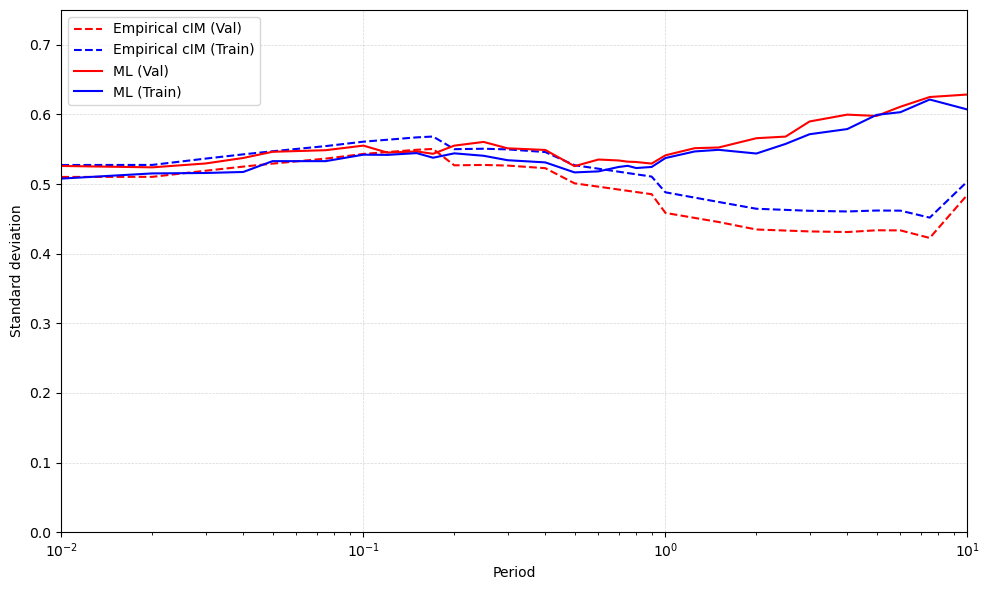

In [85]:
# Plot the standard deviation of the ML and the empirical cIM approach
fig = plt.figure(figsize=(10, 6))

plt.semilogx(sr.constants.PERIODS, val_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Val)", c="r", linestyle="--")
plt.semilogx(sr.constants.PERIODS, train_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Train)", c="b", linestyle="--")

plt.semilogx(sr.constants.PERIODS, val_sc_sum_df[ml_std_cols].mean(), label="ML (Val)", c="r")
plt.semilogx(sr.constants.PERIODS, train_sc_sum_df[ml_std_cols].mean(), label="ML (Train)",  c="b")

plt.xlabel("Period")
plt.ylabel("Standard deviation")
plt.legend()
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")

plt.xlim(0.01, 10)
plt.ylim(0, 0.75)

fig.tight_layout()
plt.show()


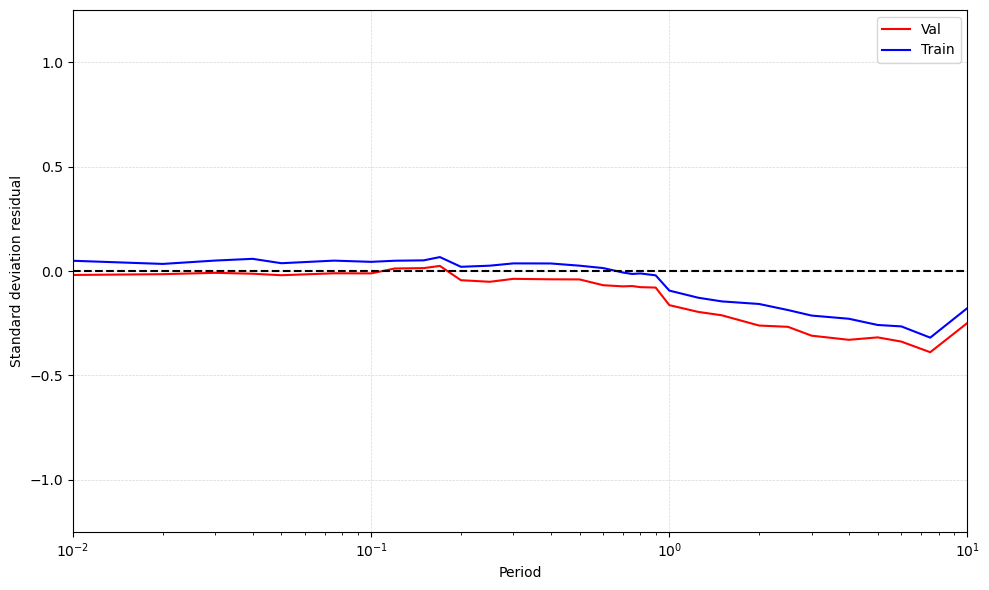

In [86]:
# Plot the residual between the standard deviations of the ML and the empirical cIM approach
fig = plt.figure(figsize=(10, 6))

plt.semilogx(sr.constants.PERIODS, val_ml_emp_std_res[sr.constants.PSA_KEYS].mean(axis=0), label="Val", c="r")
plt.semilogx(sr.constants.PERIODS, train_ml_emp_std_res[sr.constants.PSA_KEYS].mean(axis=0), label="Train", c="b")

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Period")
plt.ylabel("Standard deviation residual")
plt.legend()
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")

plt.xlim(0.01, 10)
plt.ylim(-1.25, 1.25)

fig.tight_layout()

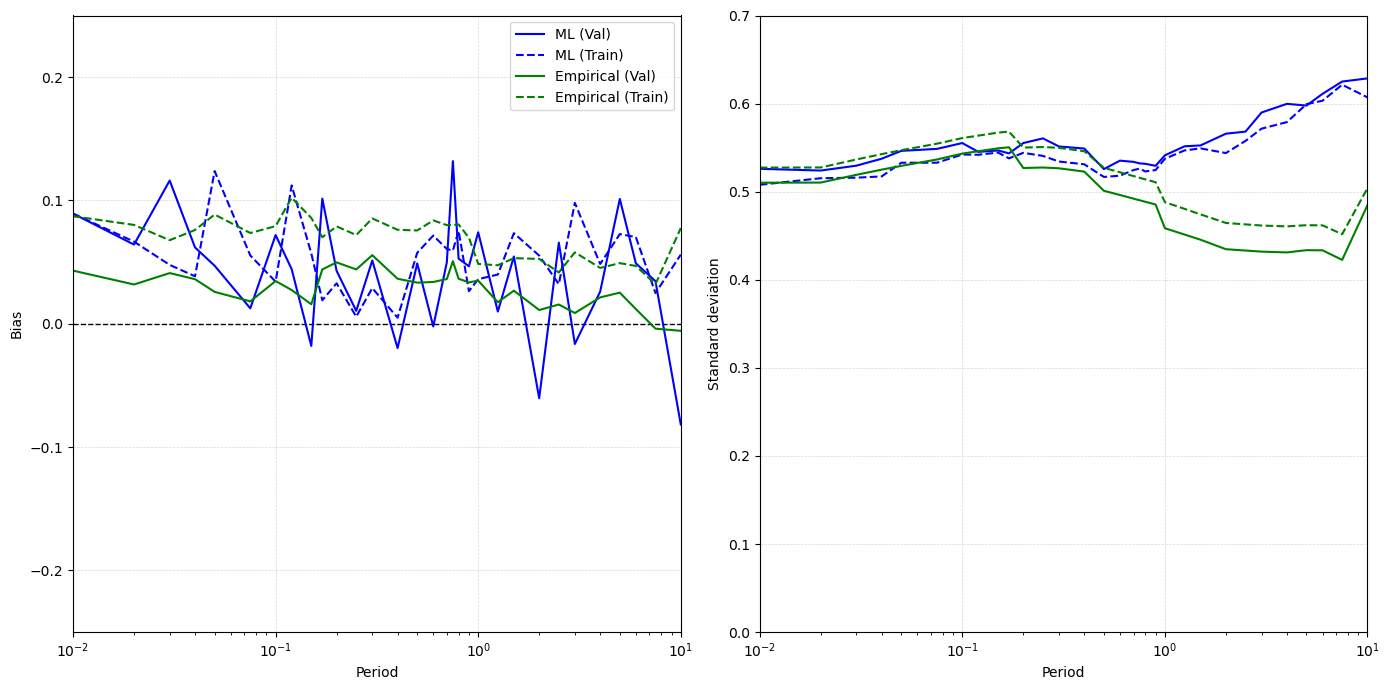

In [88]:
# Plot the bias wrt to observed, and the standard deviation of the ML and the empirical cIM approach
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

ax1.axhline(0, color="k", linestyle="--", linewidth=1.0)

ax1.semilogx(sr.constants.PERIODS, val_ml_obs_res[sr.constants.PSA_KEYS].mean(axis=0), label="ML (Val)", c="b", linestyle="-")
ax1.semilogx(sr.constants.PERIODS, train_ml_obs_res[sr.constants.PSA_KEYS].mean(axis=0), label="ML (Train)", c="b", linestyle="--")

ax1.semilogx(sr.constants.PERIODS, val_emp_obs_res[sr.constants.PSA_KEYS].mean(axis=0), label="Empirical (Val)", c="g", linestyle="-")
ax1.semilogx(sr.constants.PERIODS, train_emp_obs_res[sr.constants.PSA_KEYS].mean(axis=0), label="Empirical (Train)",c="g", linestyle="--")


ax1.set_xlim(0.01, 10)
ax1.set_ylim(-0.25, 0.25)
ax1.set_xlabel("Period")
ax1.set_ylabel("Bias")

ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.legend()


ax2.semilogx(sr.constants.PERIODS, val_sc_sum_df[ml_std_cols].mean(), label="ML (Val)", c="b", linestyle="-")
ax2.semilogx(sr.constants.PERIODS, train_sc_sum_df[ml_std_cols].mean(), label="ML (Train)", c="b", linestyle="--")

ax2.semilogx(sr.constants.PERIODS, val_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Val)", c="g", linestyle="-")
ax2.semilogx(sr.constants.PERIODS, train_emp_std_df[sr.constants.PSA_KEYS].mean(), label="Empirical cIM (Train)", c="g", linestyle="--")

ax2.set_xlim(0.01, 10)
ax2.set_ylim(0, 0.7)
ax2.set_xlabel("Period")
ax2.set_ylabel("Standard deviation")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()

What is the reason for the difference in standard deviation at short periods??

In [89]:
ml_l2_prob_columns = [f"{cur_key}_l2_prob_penalty" for cur_key in sr.constants.PSA_KEYS]
ml_sc_loss_columns = [f"{cur_key}_scenario_loss" for cur_key in sr.constants.PSA_KEYS]

KeyError: "None of [Index(['pSA_0.01_scenario_loss', 'pSA_0.02_scenario_loss',\n       'pSA_0.03_scenario_loss', 'pSA_0.04_scenario_loss',\n       'pSA_0.05_scenario_loss', 'pSA_0.075_scenario_loss',\n       'pSA_0.1_scenario_loss', 'pSA_0.12_scenario_loss',\n       'pSA_0.15_scenario_loss', 'pSA_0.17_scenario_loss',\n       'pSA_0.2_scenario_loss', 'pSA_0.25_scenario_loss',\n       'pSA_0.3_scenario_loss', 'pSA_0.4_scenario_loss',\n       'pSA_0.5_scenario_loss', 'pSA_0.6_scenario_loss',\n       'pSA_0.7_scenario_loss', 'pSA_0.75_scenario_loss',\n       'pSA_0.8_scenario_loss', 'pSA_0.9_scenario_loss',\n       'pSA_1.0_scenario_loss', 'pSA_1.25_scenario_loss',\n       'pSA_1.5_scenario_loss', 'pSA_2.0_scenario_loss',\n       'pSA_2.5_scenario_loss', 'pSA_3.0_scenario_loss',\n       'pSA_4.0_scenario_loss', 'pSA_5.0_scenario_loss',\n       'pSA_6.0_scenario_loss', 'pSA_7.5_scenario_loss',\n       'pSA_10.0_scenario_loss'],\n      dtype='object')] are in the [columns]"

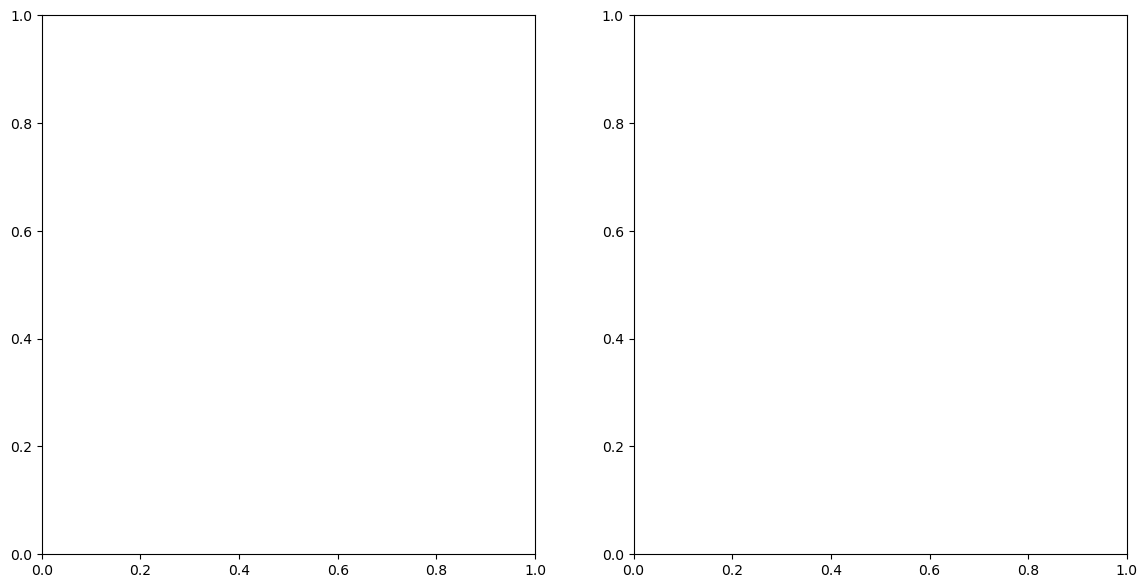

In [90]:
# Look at the L2 prob penalty as a function of period
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

val_sc_loss_mean, val_sc_loss_std = val_sc_sum_df[ml_sc_loss_columns].mean(axis=0), val_sc_sum_df[ml_sc_loss_columns].std(axis=0)  
ax1.semilogx(sr.constants.PERIODS, val_sc_loss_mean, label="Val", c="b", linestyle="-")
ax1.semilogx(sr.constants.PERIODS, val_sc_loss_mean + val_sc_loss_std, c="b", linestyle="-", linewidth=0.5)
ax1.semilogx(sr.constants.PERIODS, val_sc_loss_mean - val_sc_loss_std, c="b", linestyle="-", linewidth=0.5)

train_sc_loss_mean = train_sc_sum_df[ml_sc_loss_columns].mean(axis=0)
train_sc_loss_std = train_sc_sum_df[ml_sc_loss_columns].std(axis=0)
ax1.semilogx(sr.constants.PERIODS, train_sc_loss_mean, label="Train", c="b", linestyle="--")
ax1.semilogx(sr.constants.PERIODS, train_sc_loss_mean + train_sc_loss_std, c="b", linestyle="--", linewidth=0.5)
ax1.semilogx(sr.constants.PERIODS, train_sc_loss_mean - train_sc_loss_std, c="b", linestyle="--", linewidth=0.5)


ax1.set_ylim(0, None)
ax1.set_xlim(0.01, 10)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_ylabel("Scenario Loss")
ax1.set_xlabel("Period")

val_l2_prob_mean = val_sc_sum_df[ml_l2_prob_columns].mean(axis=0)
val_l2_prob_std = val_sc_sum_df[ml_l2_prob_columns].std(axis=0)
ax2.semilogx(sr.constants.PERIODS, val_l2_prob_mean, label="Val", c="b", linestyle="-")
# ax2.semilogx(sr.constants.PERIODS, val_l2_prob_mean + val_l2_prob_std, c="b", linestyle="-", linewidth=0.5)
# ax2.semilogx(sr.constants.PERIODS, val_l2_prob_mean - val_l2_prob_std, c="b", linestyle="-", linewidth=0.5)

train_l2_prob_mean = train_sc_sum_df[ml_l2_prob_columns].mean(axis=0)
train_l2_prob_std = train_sc_sum_df[ml_l2_prob_columns].std(axis=0)
ax2.semilogx(sr.constants.PERIODS, train_l2_prob_mean, label="Train", c="b", linestyle="--")
# ax2.semilogx(sr.constants.PERIODS, train_l2_prob_mean + train_l2_prob_std, c="b", linestyle="--", linewidth=0.5)
# ax2.semilogx(sr.constants.PERIODS, train_l2_prob_mean - train_l2_prob_std, c="b", linestyle="--", linewidth=0.5)

ax2.set_xlabel("Period")
ax2.set_ylabel("L2 Prob Penalty")
ax2.set_xlim(0.01, 10)
ax2.set_ylim(0, 0.006)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.legend()

fig.tight_layout()